### data input and kappa plot

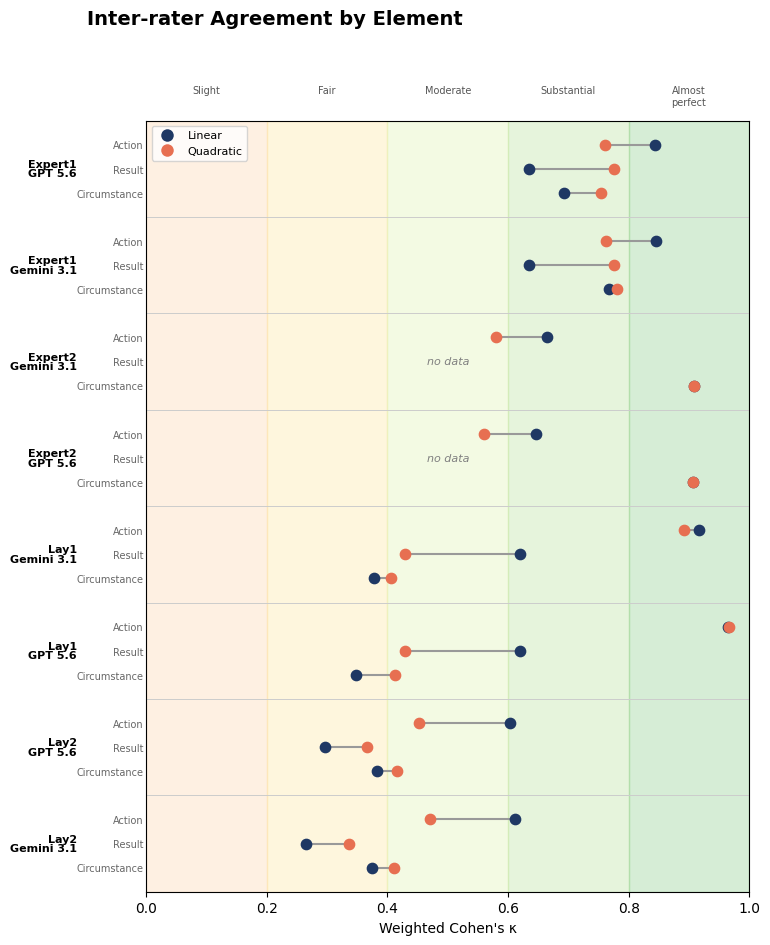

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# =====================================================================
# EDIT THIS BLOCK with your real IRR results.
#
# One entry per rater pair, labels formatted "Name1 - Name2".
# Values in element order: ELEMENTS = ["Action", "Result", "Circumstance"]
# Write "no data" (in quotes) wherever a value is missing.
# Add or remove pairs freely — the figure resizes itself.
# =====================================================================
ELEMENTS = ["Action", "Result", "Circumstance"]

PAIRS = {
    "Expert1 - GPT 5.6": {
        "k_linear":     [0.843, 0.634, 0.692],
        "k_quadratic":  [0.761, 0.776, 0.754],
        "na_agreement": [79.1, 71.6, 78.4],
        "n":            [101, 15, 102],
    },

 "Expert1 - Gemini 3.1": {
        "k_linear":     [0.845, 0.634, 0.767],
        "k_quadratic":  [0.763, 0.776, 0.781],
        "na_agreement": [80.1, 73.5, 73.5],
        "n":            [102, 15, 96],
 },
    "Expert2 - Gemini 3.1": {
        "k_linear":     [0.665, "no data", 0.908],
        "k_quadratic":  [0.58, "no data", 0.909],
        "na_agreement": [91.5, 76.5, 71.9],
        "n":            [136, 1, 62],
    },
  "Expert2 - GPT 5.6": {
        "k_linear":     [0.647, "no data", 0.906],
        "k_quadratic":  [0.56, "no data", 0.906],
        "na_agreement": [87.3, 74.5, 71.6],
        "n":            [130, 1, 60],
    },

  "Lay1 - Gemini 3.1": {
        "k_linear":     [0.917, 0.619, 0.377],
        "k_quadratic":  [0.892, 0.429, 0.406],
        "na_agreement": [88.6, 81.4, 78.8],
        "n":            [110, 16, 91],
  },
  "Lay1 - GPT 5.6": {
        "k_linear":     [0.965, 0.619, 0.348],
        "k_quadratic":  [0.967, 0.429, 0.413],
        "na_agreement": [85.0, 79.4, 80.4],
        "n":            [105, 16, 92],
    },

  "Lay2 - GPT 5.6": {
        "k_linear":     [0.604, 0.297, 0.383],
        "k_quadratic":  [0.453, 0.366, 0.416],
        "na_agreement": [83.7, 82.0, 82.0],
        "n":            [119, 31, 105],
    },
    "Lay2 - Gemini 3.1": {
        "k_linear":     [0.611, 0.265, 0.375],
        "k_quadratic":  [0.471, 0.336, 0.410],
        "na_agreement": [85.9, 84.0, 80.4],
        "n":            [122, 31, 104],
    },

}

SUPTITLE = "Inter-rater Agreement by Element"
KAPPA_XLABEL = "Weighted Cohen's \u03ba"

# Landis-Koch interpretation bands
BANDS = [
    (0.0, 0.20, "Slight", "#fdd0a2"),
    (0.20, 0.40, "Fair", "#fee391"),
    (0.40, 0.60, "Moderate", "#d9f0a3"),
    (0.60, 0.80, "Substantial", "#addd8e"),
    (0.80, 1.00, "Almost\nperfect", "#78c679"),
]

COL_LINEAR = "#1f3864"
COL_QUAD = "#e76f51"
COL_BAR = "#2a9d8f"

# Layout knobs
EL_SPACING = 0.55   # distance between element lines within a pair
GROUP_GAP  = 1.1    # gap between pair groups

# =====================================================================
# Plotting (no need to edit below)
# =====================================================================

def _to_float(values):
    """Convert a list to floats, treating 'no data' (any casing), '', and
    None as missing. np.nan still works too."""
    out = []
    for v in values:
        if v is None:
            out.append(np.nan)
        elif isinstance(v, str):
            if v.strip().lower() in ("no data", "nodata", "na", "n/a", ""):
                out.append(np.nan)
            else:
                out.append(float(v))
        else:
            out.append(float(v))
    return np.asarray(out, dtype=float)


def plot_kappa(pairs=PAIRS, elements=ELEMENTS, suptitle=SUPTITLE):
    n_pairs = len(pairs)
    n_el = len(elements)
    group_height = (n_el - 1) * EL_SPACING
    group_starts = [p * (group_height + GROUP_GAP) for p in range(n_pairs)]

    fig, ax = plt.subplots(figsize=(10, 1.05 * n_pairs + 1.2))
    fig.suptitle(suptitle, fontsize=14, fontweight="bold")

    # Landis-Koch bands + labels (labels sit above the box)
    for lo, hi, lab, c in BANDS:
        ax.axvspan(lo, hi, color=c, alpha=0.30, zorder=0)
        ax.text((lo + hi) / 2, -1.35, lab, ha="center", va="top",
                fontsize=7, color="#555")

    # Always-visible proxy legend
    legend_handles = [
        Line2D([0], [0], marker="o", linestyle="none",
               markerfacecolor=COL_LINEAR, markeredgecolor="none",
               markersize=9, label="Linear"),
        Line2D([0], [0], marker="o", linestyle="none",
               markerfacecolor=COL_QUAD, markeredgecolor="none",
               markersize=9, label="Quadratic"),
    ]

    yticks, yticklabels = [], []
    for p, (pair_name, d) in enumerate(pairs.items()):
        kl = _to_float(d["k_linear"])
        kq = _to_float(d["k_quadratic"])
        y0 = group_starts[p]

        for i in range(n_el):
            yi = y0 + i * EL_SPACING
            yticks.append(yi)
            yticklabels.append(elements[i])
            if np.isnan(kl[i]) and np.isnan(kq[i]):
                ax.text(0.5, yi, "no data", va="center", ha="center",
                        style="italic", color="grey", fontsize=8)
                continue
            lo_pt = np.nanmin([kl[i], kq[i]])
            hi_pt = np.nanmax([kl[i], kq[i]])
            # clip_on=False lets markers at kappa = 1.0 (or 0.0) draw as
            # full circles on the axis edge instead of being cut in half.
            ax.plot([lo_pt, hi_pt], [yi, yi], color="#999", zorder=2,
                    clip_on=False)
            if not np.isnan(kl[i]):
                ax.scatter(kl[i], yi, color=COL_LINEAR, s=55, zorder=3,
                           clip_on=False)
            if not np.isnan(kq[i]):
                ax.scatter(kq[i], yi, color=COL_QUAD, s=55, zorder=3,
                           clip_on=False)

        # Stacked pair title, centered on the middle (Result) line
        stacked = pair_name.replace(" - ", "\n") if " - " in pair_name else pair_name
        ax.text(-0.115, y0 + 1 * EL_SPACING, stacked,
                transform=ax.get_yaxis_transform(),
                ha="right", va="center", fontsize=8, fontweight="bold",
                linespacing=0.95)

        # Separator between pair groups
        if p < n_pairs - 1:
            ax.axhline(y0 + group_height + GROUP_GAP / 2,
                       color="#ccc", linewidth=0.7, zorder=1)

    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabels, fontsize=7, color="#666")
    ax.tick_params(axis="y", length=0, pad=2)
    ax.set_xlim(0, 1)
    ax.set_ylim(group_starts[-1] + group_height + GROUP_GAP / 2,
                -GROUP_GAP / 2)  # inverted: first pair at top
    ax.set_xlabel(KAPPA_XLABEL)
    ax.legend(handles=legend_handles, fontsize=8, loc="upper left",
              bbox_to_anchor=(0.0, 1.0))
    plt.tight_layout(rect=[0.20, 0, 1, 0.95])
    return fig


fig_kappa = plot_kappa()

### Save Kappa Plot

In [4]:
import os
SAVE_DIR = "/Users/chris/Desktop/4 Test Offense"
FILENAME = "kappa_by_pair_single_box"
os.makedirs(SAVE_DIR, exist_ok=True)
fig_kappa.savefig(f"{SAVE_DIR}/{FILENAME}.svg", bbox_inches="tight")
fig_kappa.savefig(f"{SAVE_DIR}/{FILENAME}.png", dpi=200, bbox_inches="tight")
print("Saved", FILENAME, "to", SAVE_DIR)

Saved kappa_by_pair_single_box to /Users/chris/Desktop/4 Test Offense


### NA Bar graphs

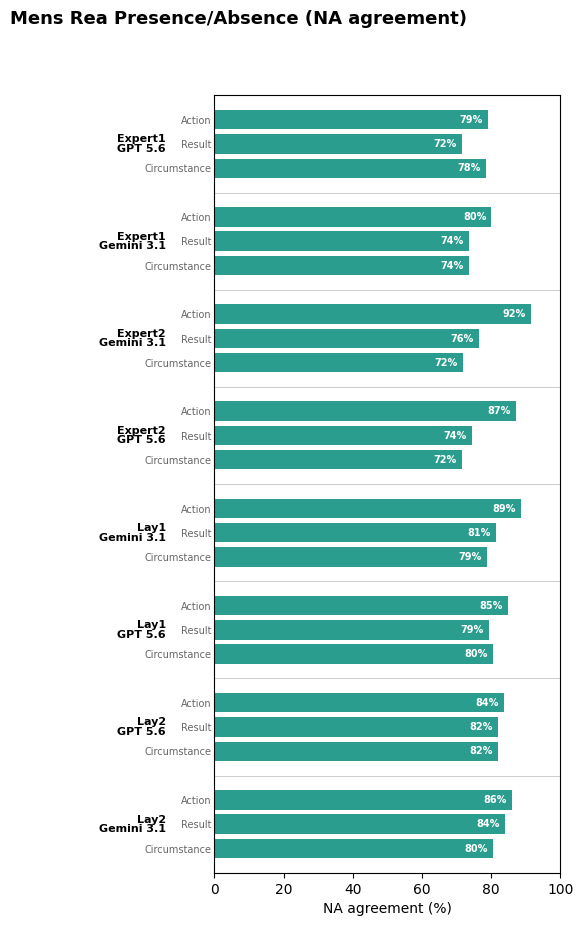

In [6]:
def plot_na(pairs=PAIRS, elements=ELEMENTS):
    n_pairs = len(pairs)
    n_el = len(elements)
    group_height = (n_el - 1) * EL_SPACING
    group_starts = [p * (group_height + GROUP_GAP) for p in range(n_pairs)]

    fig, ax = plt.subplots(figsize=(7, 1.05 * n_pairs + 1.0))
    fig.suptitle("Mens Rea Presence/Absence (NA agreement)",
                 fontsize=13, fontweight="bold")

    yticks, yticklabels = [], []
    for p, (pair_name, d) in enumerate(pairs.items()):
        na = _to_float(d["na_agreement"])
        y0 = group_starts[p]
        for i in range(n_el):
            yi = y0 + i * EL_SPACING
            yticks.append(yi)
            yticklabels.append(elements[i])
            if np.isnan(na[i]):
                continue
            ax.barh(yi, na[i], height=EL_SPACING * 0.8, color=COL_BAR)
            if na[i] >= 15:
                ax.text(na[i] - 1.5, yi, f"{na[i]:.0f}%", va="center",
                        ha="right", fontsize=7, color="white",
                        fontweight="bold")
            else:
                ax.text(na[i] + 1.5, yi, f"{na[i]:.0f}%", va="center",
                        ha="left", fontsize=7, color="#333")

        stacked = pair_name.replace(" - ", "\n") if " - " in pair_name else pair_name
        ax.text(-0.14, y0 + 1 * EL_SPACING, stacked,
                transform=ax.get_yaxis_transform(),
                ha="right", va="center", fontsize=8, fontweight="bold",
                linespacing=0.95)
        if p < n_pairs - 1:
            ax.axhline(y0 + group_height + GROUP_GAP / 2,
                       color="#ccc", linewidth=0.7)

    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabels, fontsize=7, color="#666")
    ax.tick_params(axis="y", length=0, pad=2)
    ax.set_xlim(0, 100)
    ax.set_ylim(group_starts[-1] + group_height + GROUP_GAP / 2,
                -GROUP_GAP / 2)
    ax.set_xlabel("NA agreement (%)")
    plt.tight_layout(rect=[0.24, 0, 1, 0.94])
    return fig


fig_na = plot_na()

### Save

In [ ]:
import os
SAVE_DIR = "/Users/chris/Desktop/4 Test Offense"
FILENAME = "na_agreement_by_pair"
os.makedirs(SAVE_DIR, exist_ok=True)
fig_na.savefig(f"{SAVE_DIR}/{FILENAME}.svg", bbox_inches="tight")
fig_na.savefig(f"{SAVE_DIR}/{FILENAME}.png", dpi=200, bbox_inches="tight")
print("Saved", FILENAME, "to", SAVE_DIR)